In [67]:
# Cell 1 — Imports
import numpy as np
import pandas as pd
import xarray as xr
import sys
import matplotlib.pyplot as plt
from pathlib import Path
import glob
import itur

sys.path.append(str(Path("../src").resolve()))
from radar_lwc.preprocessing.chirps import combine_chirps
from radar_lwc.preprocessing.get_reflectivity import get_reflectivity
from radar_lwc.preprocessing.clean import drop_duplicate_times
from radar_lwc.preprocessing.align import align_to_reference_time
from radar_lwc.retrieval.kappa_liquid import kappa_liquid, kappa_field
from radar_lwc.retrieval.dielectric import epsilon_water_liebe1989
from radar_lwc.retrieval.zhu import retrieve_lwc_zhu
from radar_lwc.retrieval.gas_attenuation import specific_gas_attenuation, alpha_field
from radar_lwc.retrieval.average_ze_time import avg_ze_time

In [68]:
in_path = Path("../data/processed/aligned_LWP2.nc")
ds = xr.open_dataset(in_path)
ds_alpha = xr.open_dataset("../data/processed/gas_attenuation.nc")
print(ds)

<xarray.Dataset> Size: 156MB
Dimensions:     (Time: 10441, range: 339)
Coordinates:
  * Time        (Time) datetime64[ns] 84kB 2023-09-28T07:00:04 ... 2023-09-28...
  * range       (range) float32 1kB 111.8 134.2 156.5 ... 1.194e+04 1.197e+04
    TAlt        (range) float32 1kB ...
    HAlt        (range) float32 1kB ...
Data variables:
    SLh_W       (Time, range) float32 14MB ...
    SLh_Ka      (Time, range) float32 14MB ...
    SLv_W       (Time, range) float32 14MB ...
    SLv_Ka      (Time, range) float32 14MB ...
    MeanVel_W   (Time, range) float32 14MB ...
    MeanVel_Ka  (Time, range) float32 14MB ...
    Ze_W        (Time, range) float32 14MB ...
    Ze_Ka       (Time, range) float32 14MB ...
    T_cloud     (Time, range) float32 14MB ...
    AH_cloud    (Time, range) float32 14MB ...
    P_cloud     (Time, range) float32 14MB ...
    LWP         (Time) float32 42kB ...
Attributes:
    description:    Aligned W/Ka reflectivities + T field for LWC retrieval
    date:       

===============================

KAPPA AND ALPHA CALCULATION AND PLACEHOLDERS FOR NOW

====================================

In [69]:
ds["alpha_W"] = ds_alpha["alpha_W"]
ds["alpha_Ka"] = ds_alpha["alpha_Ka"]

In [70]:
alpha_W = ds["alpha_W"]
alpha_Ka = ds["alpha_Ka"]

In [71]:
print(alpha_W)
print(alpha_Ka)

print(f"W-band:  {float(alpha_W.min()):.3f} - {float(alpha_W.max()):.3f} dB/km")
print(f"Ka-band: {float(alpha_Ka.min()):.3f} - {float(alpha_Ka.max()):.3f} dB/km")

<xarray.DataArray 'alpha_W' (Time: 10441, range: 339)> Size: 28MB
[3539499 values with dtype=float64]
Coordinates:
  * Time     (Time) datetime64[ns] 84kB 2023-09-28T07:00:04 ... 2023-09-28T14...
  * range    (range) float32 1kB 111.8 134.2 156.5 ... 1.194e+04 1.197e+04
    TAlt     (range) float32 1kB ...
    HAlt     (range) float32 1kB ...
Attributes:
    units:      dB km-1
    long_name:  Gaseous attenuation at 94.0 GHz
    model:      ITU-R P.676
<xarray.DataArray 'alpha_Ka' (Time: 10441, range: 339)> Size: 28MB
[3539499 values with dtype=float64]
Coordinates:
  * Time     (Time) datetime64[ns] 84kB 2023-09-28T07:00:04 ... 2023-09-28T14...
  * range    (range) float32 1kB 111.8 134.2 156.5 ... 1.194e+04 1.197e+04
    TAlt     (range) float32 1kB ...
    HAlt     (range) float32 1kB ...
Attributes:
    units:      dB km-1
    long_name:  Gaseous attenuation at 35.0 GHz
    model:      ITU-R P.676
W-band:  0.007 - 0.654 dB/km
Ka-band: 0.005 - 0.145 dB/km


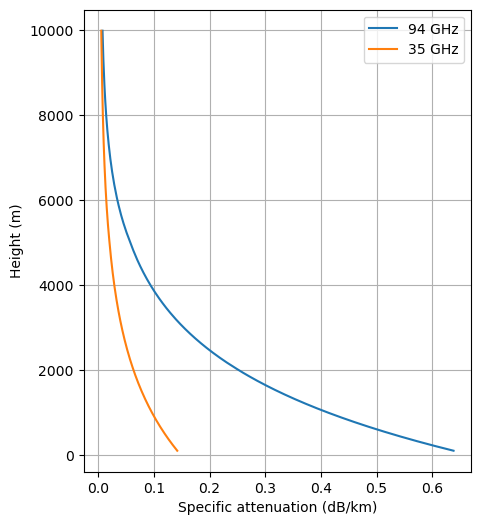

In [72]:
import matplotlib.pyplot as plt

t = 0

plt.figure(figsize=(5, 6))

plt.plot(alpha_W.isel(Time=t), alpha_W["range"], label="94 GHz")
plt.plot(alpha_Ka.isel(Time=t), alpha_Ka["range"], label="35 GHz")

plt.xlabel("Specific attenuation (dB/km)")
plt.ylabel("Height (m)")
plt.legend()
plt.grid()

plt.show()

In [73]:
# W-band (94 GHz)
kappa_W = kappa_field(
    T_field=ds["T_cloud"],
    freq_ghz=94.0,
)

# Ka-band (35 GHz)
kappa_Ka = kappa_field(
    T_field=ds["T_cloud"],
    freq_ghz=35.0,
)

C:\Projects\Masterarbeit\dual_freq_radar_lwc\src\radar_lwc\retrieval\dielectric.py:51: RuntimeWarning: invalid value encountered in divide
  eps = (eps0 - eps1) / (1.0 + 1j * (freq_ghz / f_p)) \
C:\Projects\Masterarbeit\dual_freq_radar_lwc\src\radar_lwc\retrieval\dielectric.py:52: RuntimeWarning: invalid value encountered in divide
  + (eps1 - eps2) / (1.0 + 1j * (freq_ghz / f_s)) \
C:\Projects\Masterarbeit\dual_freq_radar_lwc\src\radar_lwc\retrieval\kappa_liquid.py:29: RuntimeWarning: invalid value encountered in divide
  K     = (eps - 1.0) / (eps + 2.0)            # dielectric factor (note +2, not +1!)


In [74]:
kappa = kappa_liquid (94.0, 283)
print(kappa)

4.296428658606702


In [75]:
print(kappa_W)
print(kappa_Ka)

print(f"W-band:  {float(kappa_W.min()):.3f} - {float(kappa_W.max()):.3f} dB km⁻¹ (g m⁻³)⁻¹")
print(f"Ka-band: {float(kappa_Ka.min()):.3f} - {float(kappa_Ka.max()):.3f} dB km⁻¹ (g m⁻³)⁻¹")

<xarray.DataArray 'kappa_94GHz' (Time: 10441, range: 339)> Size: 14MB
array([[3.9909406, 3.998707 , 4.006476 , ...,       nan,       nan,
              nan],
       [3.9909406, 3.998707 , 4.006476 , ...,       nan,       nan,
              nan],
       [3.9909406, 3.998707 , 4.006476 , ...,       nan,       nan,
              nan],
       ...,
       [3.8478606, 3.855489 , 3.863127 , ...,       nan,       nan,
              nan],
       [3.8478606, 3.855489 , 3.863127 , ...,       nan,       nan,
              nan],
       [3.8478606, 3.855489 , 3.863127 , ...,       nan,       nan,
              nan]], shape=(10441, 339), dtype=float32)
Coordinates:
  * Time     (Time) datetime64[ns] 84kB 2023-09-28T07:00:04 ... 2023-09-28T14...
  * range    (range) float32 1kB 111.8 134.2 156.5 ... 1.194e+04 1.197e+04
    TAlt     (range) float32 1kB ...
    HAlt     (range) float32 1kB ...
Attributes:
    units:      dB km-1 (g m-3)-1
    long_name:  Rayleigh attenuation coefficient at 94.0 GHz
    

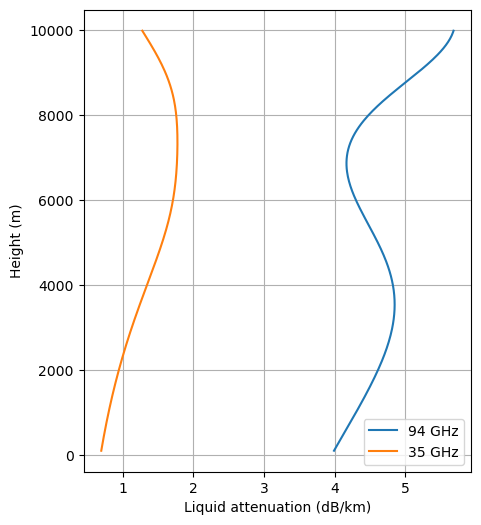

In [76]:
import matplotlib.pyplot as plt

t = 0

plt.figure(figsize=(5, 6))

plt.plot(kappa_W.isel(Time=t), kappa_W["range"], label="94 GHz")
plt.plot(kappa_Ka.isel(Time=t), kappa_Ka["range"], label="35 GHz")

plt.xlabel("Liquid attenuation (dB/km)")
plt.ylabel("Height (m)")
plt.legend()
plt.grid()

plt.show()

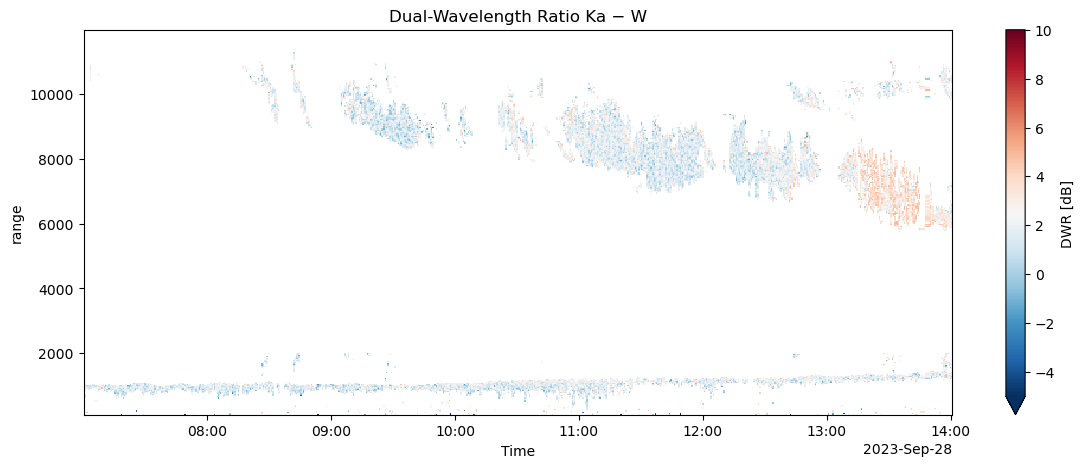

In [77]:
dwr = ds["Ze_Ka"]- ds["Ze_W"]      # in dB
dwr.name = "DWR"
dwr.attrs["units"] = "dB"
dwr = dwr.where(dwr <= 5)
fig, ax = plt.subplots(figsize=(14, 5))
dwr.plot(x="Time", y="range", cmap="RdBu_r", vmin=-5, vmax=10, ax=ax, cbar_kwargs={"label": "DWR [dB]"})
ax.set_title("Dual-Wavelength Ratio Ka − W")
plt.show()

In [78]:
alpha_w = xr.DataArray(
    np.full_like(dwr.values, 0.65),
    dims=dwr.dims,
    coords=dwr.coords,
    name="alpha_W",
)

alpha_ka = xr.DataArray(
    np.full_like(dwr.values, 0.14),
    dims=dwr.dims,
    coords=dwr.coords,
    name="alpha_Ka",
)

In [79]:
kappa_w = xr.DataArray(
    np.full_like(dwr.values, 4.29),
    dims=dwr.dims,
    coords=dwr.coords,
    name="kappa_W",
)

kappa_ka = xr.DataArray(
    np.full_like(dwr.values, 0.80),
    dims=dwr.dims,
    coords=dwr.coords,
    name="kappa_Ka",
)

=================================================

DWR

=================================================

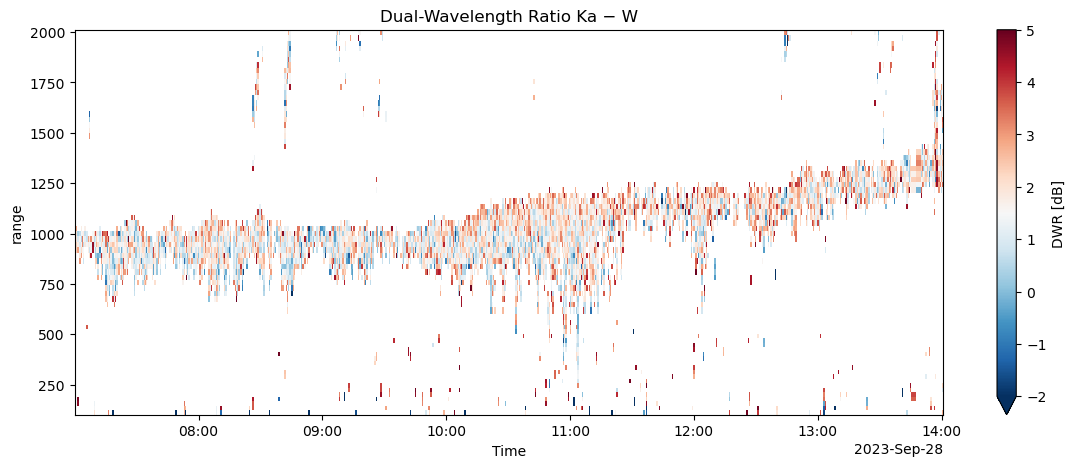

In [80]:
dwr_2km = dwr.sel(range=slice(0, 2000))

fig, ax = plt.subplots(figsize=(14, 5))

dwr_2km.plot(
    x="Time",
    y="range",
    cmap="RdBu_r",
    vmin=-2,
    vmax=5,
    ax=ax,
    cbar_kwargs={"label": "DWR [dB]"}
)

ax.set_title("Dual-Wavelength Ratio Ka − W")
plt.show()

In [81]:
# %% Check frequency of >1 dB gate-to-gate DWR jumps

dwr_2km_diff = np.abs(dwr_2km.diff(dim="range"))

fraction = float((dwr_2km_diff > 1.0).mean())

print(f"Fraction of gate-to-gate DWR jumps > 1 dB: {fraction:.2%}")

Fraction of gate-to-gate DWR jumps > 1 dB: 3.42%


In [82]:
# 1. Confirm DWR is in dB
print("DWR stats (cloud only):")
cloud_dwr = dwr.where(dwr > -5).where(dwr < 20)  # rough cloud filter
print(f"  median: {float(cloud_dwr.median()):.2f}")
print(f"  90th pct: {float(cloud_dwr.quantile(0.9)):.2f}")       # 90% of DWR are below 4.49dB
print(f"  range: {float(cloud_dwr.min()):.2f} to {float(cloud_dwr.max()):.2f}")

# 2. Confirm range axis
print(f"\nRange axis: first={float(dwr['range'][0]):.1f} m, last={float(dwr['range'][-1]):.1f} m")
print(f"Δh = {float(dwr['range'][1] - dwr['range'][0]):.1f} m")

# 3. Check kappa
print(f"\nkappa_W: {float(kappa_w.mean()):.3f} dB/km/(g/m³)")
print(f"kappa_Ka: {float(kappa_ka.mean()):.3f} dB/km/(g/m³)")
print(f"Δκ: {float((kappa_w - kappa_ka).mean()):.3f}")


DWR stats (cloud only):
  median: 1.88
  90th pct: 3.52
  range: -5.00 to 5.00

Range axis: first=111.8 m, last=11974.8 m
Δh = 22.4 m

kappa_W: 4.290 dB/km/(g/m³)
kappa_Ka: 0.800 dB/km/(g/m³)
Δκ: 3.490


====================================

CLOUD MASK

====================================

In [139]:
SL_W  = ds["SLv_W"]      # or ds["SLh_W"]
SL_Ka = ds["SLv_Ka"]      # or ds["SLh_Ka"]

SLv_W_dBZ  = 10 * np.log10(ds["SLv_W"])
SLv_Ka_dBZ = 10 * np.log10(ds["SLv_Ka"])

cloud_mask = (
    ds["Ze_Ka"].notnull()
    & ds["Ze_W"].notnull()
    & (ds["Ze_Ka"] > SLv_Ka_dBZ + 15)  # Use the sensitivity limit in dBZ
    & (ds["Ze_W"] > SLv_W_dBZ + 15)
)
cloud_mask.name = "cloud_mask"
print(f"Cloud fraction (full column): {float(cloud_mask.mean()):.2%}")     # .2: two digits after decimal and %: that in percentage; .mean of Boolean array takes true as 1 and false as 0. So True divided by all Booleans in Array 

# 2 km version to match your existing workflow
cloud_mask_2km = cloud_mask.sel(range=slice(0, 2000))                  #.sel(range=slice(0, 2000)) only takes first 2 km
print(f"Cloud fraction (0–2 km):     {float(cloud_mask_2km.mean()):.2%}")


Cloud fraction (full column): 6.55%
Cloud fraction (0–2 km):     12.10%


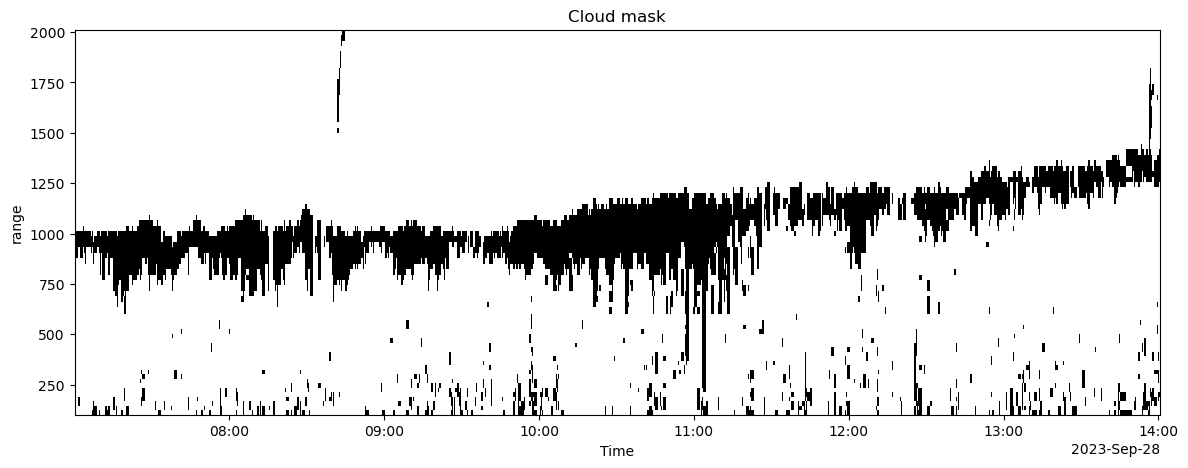

In [140]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 5))

cloud_mask.sel(range=slice(0, 2000)).plot(
    x="Time",
    y="range",
    cmap="Greys",
    add_colorbar=False,
    ax=ax,
)

ax.set_title("Cloud mask")
plt.show()

BOXFILTER

In [263]:
# %% 5x5 neighbour filter (Zhu 2019): >=13 significant returns in 5(time)x5(range) box
from scipy.ndimage import uniform_filter

min_neighbours = 13
box = (5, 5)  # (Time, range) — adjust order if your dims are (range, Time)

def neighbour_filter(significant):
    """significant: boolean DataArray (Time, range) of valid/above-noise returns."""
    window_size = box[0] * box[1]
    count = (
    uniform_filter(                     # uniform filter checks if significant (the reflectivity assumptions) is True in a 5x5 box around each gate, and counts how many are True. The multiplication by (box[0] * box[1])(5 * 5) scales the result to the number of gates in the box.
        significant.astype(float),
        size=box,
        mode="reflect"      # Mirror the data at the edge
    )
    * window_size
)                     
    return xr.DataArray(count >= min_neighbours, dims=significant.dims, coords=significant.coords)          # returns dataarray where True means enough adjacent cells are fulfilling the criteria (i.e. are True). False means not enough adjacent cells are fulfilling the criteria (i.e. are False).

sig_W  = ds["Ze_W"].notnull()  & (ds["Ze_W"]  > SLv_W_dBZ +  11)                        #Same as cloud mask before
sig_Ka = ds["Ze_Ka"].notnull() & (ds["Ze_Ka"] > SLv_Ka_dBZ +  11)                        #Same as cloud mask before

neighbour_mask_W  = neighbour_filter(sig_W)
neighbour_mask_Ka = neighbour_filter(sig_Ka)

Ze_W_filt  = ds["Ze_W"].where(sig_W  & neighbour_mask_W)                  # Both the Value itself and enough neighbours have to be significant.
Ze_Ka_filt = ds["Ze_Ka"].where(sig_Ka & neighbour_mask_Ka)
print(f"Ka-band gates removed: {float((sig_Ka & ~neighbour_mask_Ka).sum())}")

common_mask = (
    sig_W & neighbour_mask_W &
    sig_Ka & neighbour_mask_Ka
)                                      # Both Masks together

Ka-band gates removed: 62191.0


In [264]:
ze_ka_avg = avg_ze_time(ds["Ze_Ka"].sel(range=slice(0, 2000)), window_s=30)
ze_w_avg  = avg_ze_time(ds["Ze_W"].sel(range=slice(0, 2000)),  window_s=30)

dwr_2km_smoothed = ze_ka_avg - ze_w_avg
dwr_2km_smoothed.name = "DWR"

In [265]:
gate_threshold = 1.0  # dB

def despike_1d(dwr_1d, threshold=1.0):
    out = dwr_1d.copy()
    n = len(dwr_1d)
    for i in range(1, n - 1):
        left = dwr_1d[i] - dwr_1d[i - 1]
        right = dwr_1d[i] - dwr_1d[i + 1]
        is_spike = (
            np.abs(left) > threshold
            and np.abs(right) > threshold
            and np.sign(left) == np.sign(right)
        )
        if is_spike and not (np.isnan(dwr_1d[i - 1]) or np.isnan(dwr_1d[i + 1]) or np.isnan(dwr_1d[i])):
            out[i] = dwr_1d[i - 1] + (dwr_1d[i + 1] - dwr_1d[i - 1]) * 0.5
    return out

dwr_2km_filt = xr.apply_ufunc(
    despike_1d, dwr_2km_smoothed,
    input_core_dims=[["range"]], output_core_dims=[["range"]],
    kwargs={"threshold": gate_threshold}, vectorize=True,
)
dwr_2km_filt.name = "DWR"
dwr_2km_filt.attrs = dwr_2km_smoothed.attrs

n_replaced = int((np.abs(dwr_2km_filt - dwr_2km_smoothed) > 1e-9).sum())
print(f"Gates replaced by interpolation: {n_replaced} "
      f"({n_replaced / dwr_2km_smoothed.size:.2%} of all gates)")


Gates replaced by interpolation: 58605 (7.59% of all gates)


In [266]:
for margin in [0, 1, 2, 3, 5, 7, 9, 11, 13, 15, 17, 19]:
    sig_W_m  = ds["Ze_W"].notnull()  & (ds["Ze_W"]  > SLv_W_dBZ  + margin)
    sig_Ka_m = ds["Ze_Ka"].notnull() & (ds["Ze_Ka"] > SLv_Ka_dBZ + margin)
    m = sig_W_m & neighbour_filter(sig_W_m) & sig_Ka_m & neighbour_filter(sig_Ka_m)
    D = dwr_2km_filt.where(m).values
    d = D[:, 1:] - D[:, :-1]; d = d[np.isfinite(d)]
    print(f"margin={margin} dB | kept={float(m.mean()):6.2%} | "
          f"sigma_DWR={np.std(d)/np.sqrt(2):.2f} dB | "
          f"implied LWP noise={np.std(d)/np.sqrt(2)*np.sqrt(2)/(2*3.4)*1000:5.0f} g/m2")
    #I put margin on the Threshold and see for mask where it changes anything for dwr. Then I look at the Noise standard deviation which is sigma DWR and the implied LWP Noise
    # For implied noise equation same reasoning as in 05_lwc_dq for implied noise: We look at the Variance of LWP=(DWRtop​−DWRbase)/(2Δκ)*​​1000.    For each Measurement of DWR they have Variance σ^2. Subtracting them gives Var(DWRtop​−DWRbase​)=2σ^2   --> So: σ_span= sqrt(2) * σ. Thats why np.sqrt(2)

margin=0 dB | kept= 8.46% | sigma_DWR=0.51 dB | implied LWP noise=  106 g/m2
margin=1 dB | kept= 8.46% | sigma_DWR=0.51 dB | implied LWP noise=  106 g/m2
margin=2 dB | kept= 8.46% | sigma_DWR=0.51 dB | implied LWP noise=  106 g/m2
margin=3 dB | kept= 8.45% | sigma_DWR=0.51 dB | implied LWP noise=  106 g/m2
margin=5 dB | kept= 8.45% | sigma_DWR=0.51 dB | implied LWP noise=  105 g/m2
margin=7 dB | kept= 8.43% | sigma_DWR=0.50 dB | implied LWP noise=  104 g/m2
margin=9 dB | kept= 8.30% | sigma_DWR=0.48 dB | implied LWP noise=  100 g/m2
margin=11 dB | kept= 7.81% | sigma_DWR=0.46 dB | implied LWP noise=   95 g/m2
margin=13 dB | kept= 6.96% | sigma_DWR=0.42 dB | implied LWP noise=   87 g/m2
margin=15 dB | kept= 5.99% | sigma_DWR=0.37 dB | implied LWP noise=   77 g/m2
margin=17 dB | kept= 4.98% | sigma_DWR=0.32 dB | implied LWP noise=   67 g/m2
margin=19 dB | kept= 3.92% | sigma_DWR=0.29 dB | implied LWP noise=   60 g/m2


margin= 0 dB | kept=  8.5% | sigma_DWR=0.507 dB | LWP noise=105.5 g/m²
margin= 1 dB | kept=  8.5% | sigma_DWR=0.507 dB | LWP noise=105.5 g/m²
margin= 2 dB | kept=  8.5% | sigma_DWR=0.507 dB | LWP noise=105.5 g/m²
margin= 3 dB | kept=  8.5% | sigma_DWR=0.508 dB | LWP noise=105.6 g/m²
margin= 5 dB | kept=  8.5% | sigma_DWR=0.506 dB | LWP noise=105.1 g/m²
margin= 7 dB | kept=  8.4% | sigma_DWR=0.499 dB | LWP noise=103.7 g/m²
margin= 9 dB | kept=  8.3% | sigma_DWR=0.483 dB | LWP noise=100.4 g/m²
margin=11 dB | kept=  7.8% | sigma_DWR=0.458 dB | LWP noise=95.3 g/m²
margin=13 dB | kept=  7.0% | sigma_DWR=0.417 dB | LWP noise=86.6 g/m²
margin=15 dB | kept=  6.0% | sigma_DWR=0.372 dB | LWP noise=77.4 g/m²
margin=17 dB | kept=  5.0% | sigma_DWR=0.320 dB | LWP noise=66.5 g/m²
margin=19 dB | kept=  3.9% | sigma_DWR=0.287 dB | LWP noise=59.6 g/m²


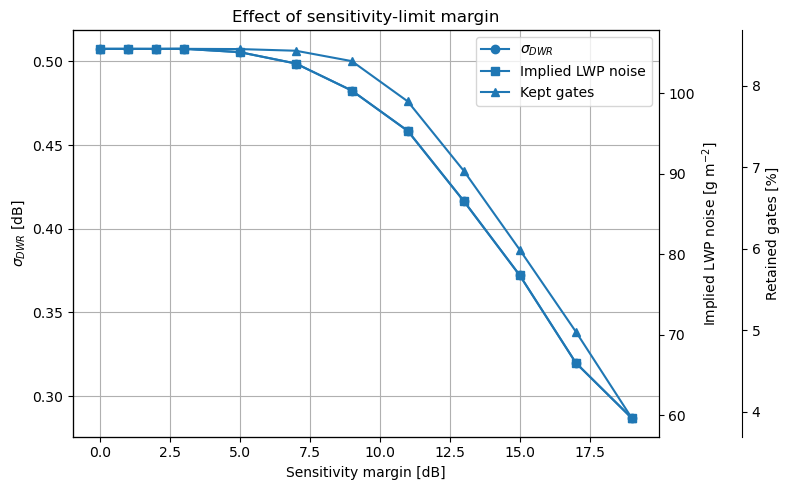

In [267]:
margins = [0, 1, 2, 3, 5, 7, 9, 11, 13, 15, 17, 19]

kept_fraction = []
sigma_dwr = []
lwp_noise = []

for margin in margins:

    # --- sensitivity mask with additional margin ---
    sig_W_m = ds["Ze_W"].notnull() & (ds["Ze_W"] > (SLv_W_dBZ + margin))
    sig_Ka_m = ds["Ze_Ka"].notnull() & (ds["Ze_Ka"] > (SLv_Ka_dBZ + margin))

    m = (
        sig_W_m
        & neighbour_filter(sig_W_m)
        & sig_Ka_m
        & neighbour_filter(sig_Ka_m)
    )

    # --- estimate DWR noise ---
    D = dwr_2km_filt.where(m).values
    diffs = D[:, 1:] - D[:, :-1]
    diffs = diffs[np.isfinite(diffs)]

    sigma = np.std(diffs) / np.sqrt(2)

    kept_fraction.append(float(m.mean()) * 100)
    sigma_dwr.append(sigma)
    lwp_noise.append(sigma * np.sqrt(2) / (2 * 3.4) * 1000)

    print(
        f"margin={margin:>2} dB | "
        f"kept={kept_fraction[-1]:5.1f}% | "
        f"sigma_DWR={sigma:.3f} dB | "
        f"LWP noise={lwp_noise[-1]:.1f} g/m²"
    )

# ------------------------------------------------------------------
# Plot
# ------------------------------------------------------------------
fig, ax1 = plt.subplots(figsize=(8,5))

ax1.plot(margins, sigma_dwr, "o-", label=r"$\sigma_{DWR}$")
ax1.set_xlabel("Sensitivity margin [dB]")
ax1.set_ylabel(r"$\sigma_{DWR}$ [dB]")
ax1.grid(True)

ax2 = ax1.twinx()
ax2.plot(margins, lwp_noise, "s-", label="Implied LWP noise")
ax2.set_ylabel("Implied LWP noise [g m$^{-2}$]")

ax3 = ax1.twinx()
ax3.spines["right"].set_position(("outward", 60))
ax3.plot(margins, kept_fraction, "^-", label="Kept gates")
ax3.set_ylabel("Retained gates [%]")

# Combined legend
lines = ax1.get_lines() + ax2.get_lines() + ax3.get_lines()
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="best")

plt.title("Effect of sensitivity-limit margin")
plt.tight_layout()
plt.show()

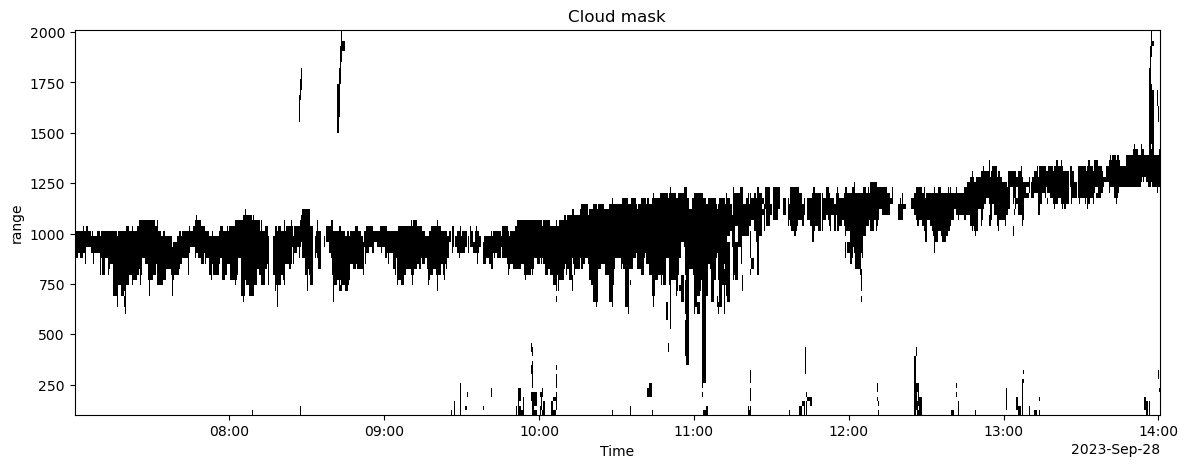

In [268]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 5))

common_mask.sel(range=slice(0, 2000)).plot(
    x="Time",
    y="range",
    cmap="Greys",
    add_colorbar=False,
    ax=ax,
)

ax.set_title("Cloud mask")
plt.show()

DRIZZLE MASK

In [269]:
# %% Drizzle filter (Hogan 2005 / Zhu 2019): |v_W - v_Ka| > 0.1 m/s
dv_threshold = 0.137  # m/sAdd

dv = (ds["MeanVel_W"] - ds["MeanVel_Ka"]).where(common_mask)    # Velocity difference at cloud_masked gates; .where(cloud_mask) keeps only the values where cloud_mask is True, and sets the rest to NaN.

min_drizzle_height = 550   # m
max_drizzle_height = 1450  # m

dv = dv.where(
    (dv["range"] >= min_drizzle_height)
    & (dv["range"] <= max_drizzle_height)
)

gate_flag = np.abs(dv) > dv_threshold          # Is this gate above the drizzle threshold?
profile_flag = gate_flag.any(dim="range")       # Does this profile contain any drizzle gate? -> whole profile is true in that range. 

drizzle_mask = ~profile_flag                    # True = keep profile, False = reject profile   (Negates the profile_flag, so that True means keep and False means reject)
drizzle_mask.name = "drizzle_mask"

print(f"Profiles removed by drizzle filter: {float(profile_flag.mean()):.2%}")

Profiles removed by drizzle filter: 21.30%


In [270]:
# %% Drizzle diagnostics

max_dv = np.abs(dv).max(dim="range")

n_exceed = gate_flag.sum(dim="range")

fraction_exceed = (
    gate_flag.sum(dim="range")
    / cloud_mask.sum(dim="range")
)

print(f"Median max |Δv|: {float(max_dv.median()):.3f} m/s")
print(f"Median exceeding gates: {float(n_exceed.median()):.1f}")
print(f"Median fraction exceeding: {float(fraction_exceed.median()):.2%}")
print(n_exceed.quantile([0.5, 0.75, 0.9, 0.95, 0.99]))

Median max |Δv|: 0.090 m/s
Median exceeding gates: 0.0
Median fraction exceeding: 0.00%
<xarray.DataArray (quantile: 5)> Size: 40B
array([0., 0., 1., 2., 4.])
Coordinates:
  * quantile  (quantile) float64 40B 0.5 0.75 0.9 0.95 0.99


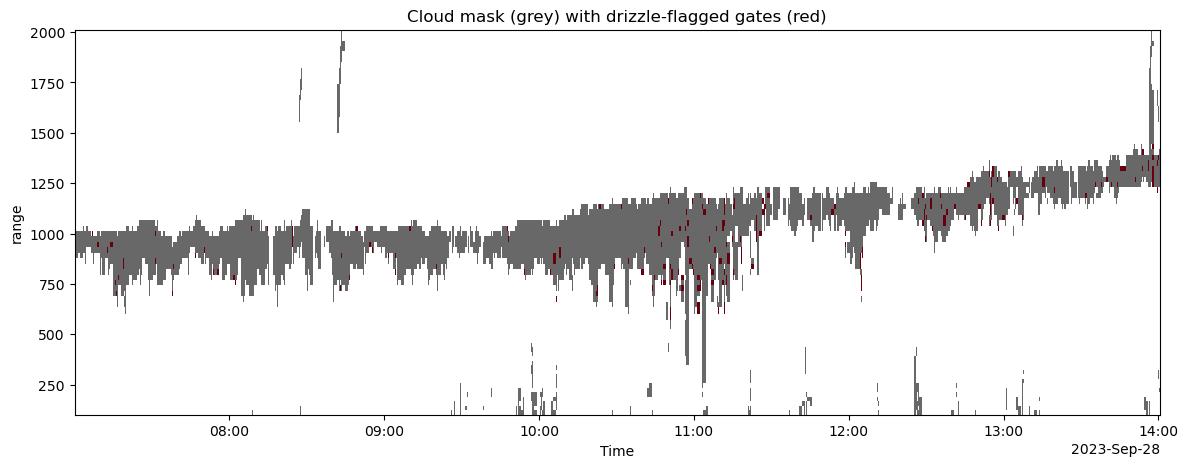

Drizzle-flagged fraction within cloud: 1.23%


In [271]:
# %% Plot common_mask + drizzle_mask together
fig, ax = plt.subplots(figsize=(14, 5))

# Background: cloud mask (grey)
common_mask.sel(range=slice(0, 2000)).plot(
    x="Time", y="range", cmap="Greys", vmin=0, vmax=1.5,
    add_colorbar=False, ax=ax,
)

# Overlay: drizzle-flagged gates (red), only where cloud is present
gate_flag_plot = gate_flag.sel(range=slice(0, 2000))
gate_flag_plot.where(gate_flag_plot).plot(
    x="Time", y="range", cmap="Reds", vmin=0, vmax=1,
    add_colorbar=False, ax=ax,
)

ax.set_title("Cloud mask (grey) with drizzle-flagged gates (red)")
plt.show()

print(f"Drizzle-flagged fraction within cloud: "
      f"{float(gate_flag.sum() / common_mask.sum()):.2%}")

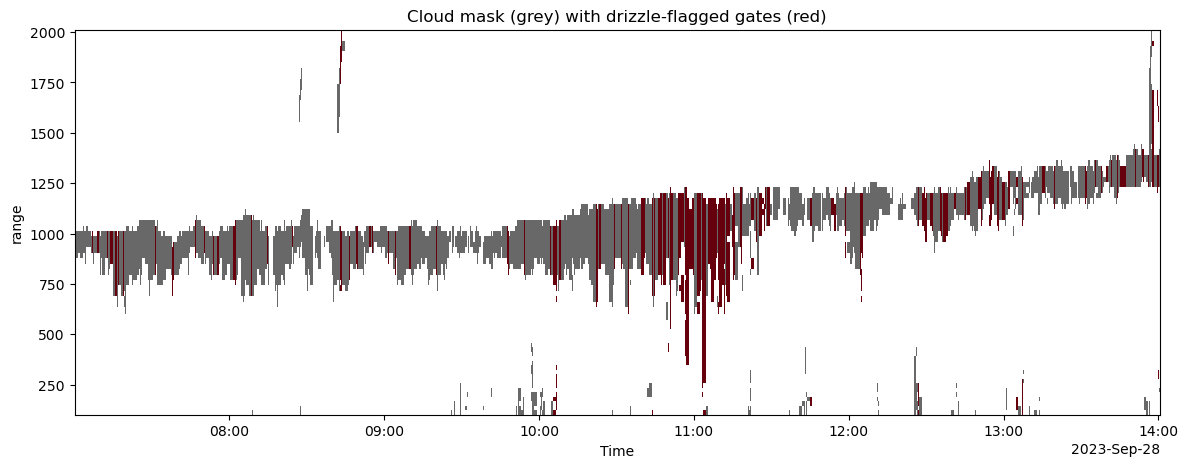

Drizzle-flagged fraction within cloud: 25.36%


In [272]:
# %% Plot common_mask + drizzle_mask together
fig, ax = plt.subplots(figsize=(14, 5))

# Background: cloud mask (grey)
common_mask.sel(range=slice(0, 2000)).plot(
    x="Time", y="range", cmap="Greys", vmin=0, vmax=1.5,
    add_colorbar=False, ax=ax,
)

# Overlay: drizzle-flagged gates (red), only where cloud is present
drizzle_flag_plot = (~drizzle_mask & common_mask).sel(range=slice(0, 2000))
drizzle_flag_plot.where(drizzle_flag_plot).plot(
    x="Time", y="range", cmap="Reds", vmin=0, vmax=1,
    add_colorbar=False, ax=ax,
)

ax.set_title("Cloud mask (grey) with drizzle-flagged gates (red)")
plt.show()

print(f"Drizzle-flagged fraction within cloud: "
      f"{float((~drizzle_mask & common_mask).sum() / common_mask.sum()):.2%}")

Text(0, 0.5, 'Profiles')

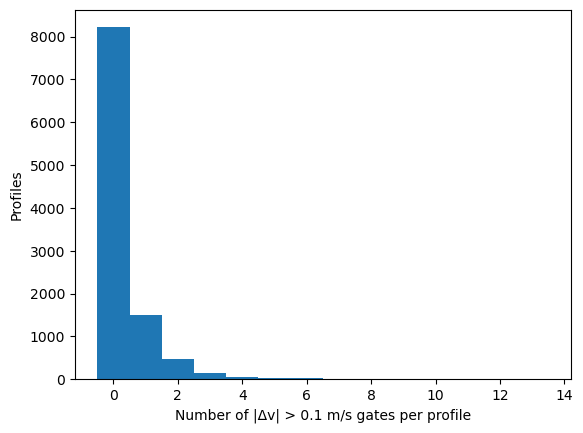

In [273]:
n_exceed = gate_flag.sum(dim="range")

plt.hist(n_exceed, bins=np.arange(0, 15) - 0.5)
plt.xlabel("Number of |Δv| > 0.1 m/s gates per profile")
plt.ylabel("Profiles")

In [274]:
# %% Diagnose the drizzle-filter kill rate
dv = (ds["MeanVel_W"] - ds["MeanVel_Ka"]).where(common_mask)
dv_vals = dv.values[np.isfinite(dv.values)]
print(f"velocity-difference: mean={dv_vals.mean():+.3f}  std={dv_vals.std():.3f} m/s")
print(f"median={np.median(dv_vals):+.3f}  |  fraction |dv|>0.1: {(np.abs(dv_vals)>0.1).mean():.1%}")
# Is the exceedance near cloud base (real drizzle) or everywhere (mismatch/noise)?

velocity-difference: mean=+0.006  std=0.088 m/s
median=+0.002  |  fraction |dv|>0.1: 8.6%


In [275]:
med = np.median(dv_vals)
mad = np.median(np.abs(dv_vals - med))
sigma_robust = 1.4826 * mad
print(f"sigma_robust (MAD) = {sigma_robust:.3f} m/s   vs std = {dv_vals.std():.3f}")
for k in [3, 4, 5]:
    thr = k * sigma_robust
    print(f"  {k}·sigma_robust = {thr:.3f} m/s -> flags {(np.abs(dv_vals)>thr).mean():.1%} of gates")
print("percentiles of |dv|:", np.percentile(np.abs(dv_vals), [90, 95, 99]).round(3))

sigma_robust (MAD) = 0.046 m/s   vs std = 0.088
  3·sigma_robust = 0.139 m/s -> flags 4.6% of gates
  4·sigma_robust = 0.185 m/s -> flags 2.7% of gates
  5·sigma_robust = 0.231 m/s -> flags 1.7% of gates
percentiles of |dv|: [0.092 0.133 0.311]


Fraction retained (common_mask & drizzle_mask): 5.73%
Fraction retained by common_mask alone:         7.68%


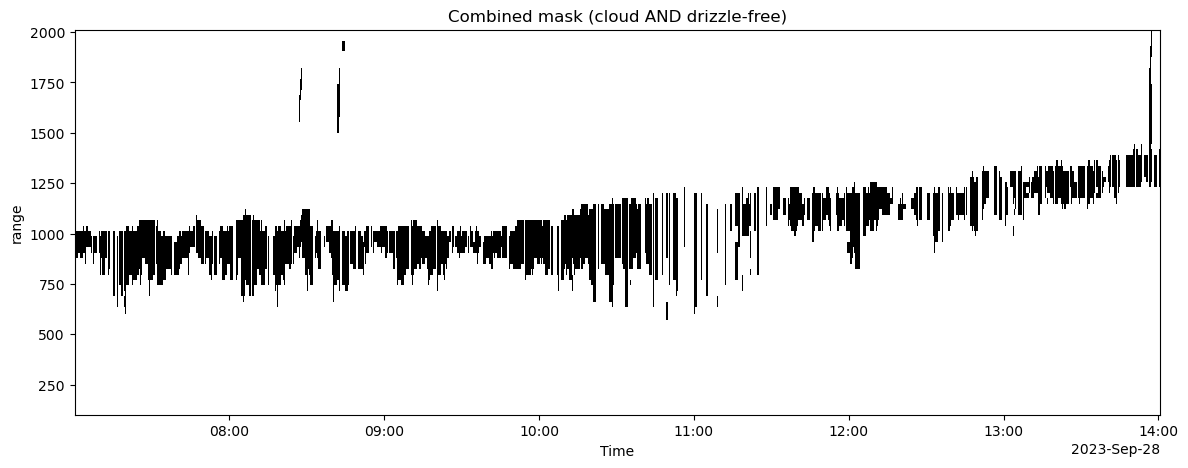

In [276]:
# %% Combine common_mask AND drizzle_mask into one mask
combined_mask = common_mask & drizzle_mask
combined_mask.name = "combined_mask"

combined_mask = combined_mask.where(combined_mask["range"] >= 500, False)
common_mask = common_mask.where(common_mask["range"] >= 500, False)

print(f"Fraction retained (common_mask & drizzle_mask): {float(combined_mask.mean()):.2%}")
print(f"Fraction retained by common_mask alone:         {float(common_mask.mean()):.2%}")

# %% Plot
fig, ax = plt.subplots(figsize=(14, 5))

combined_mask.sel(range=slice(0, 2000)).plot(
    x="Time", y="range", cmap="Greys",
    add_colorbar=False, ax=ax,
)

ax.set_title("Combined mask (cloud AND drizzle-free)")
plt.show()

In [277]:
combined_mask = (
    cloud_mask
    & sig_W & neighbour_mask_W
    & sig_Ka & neighbour_mask_Ka
    & drizzle_mask
)
combined_mask.name = "combined_mask"

dwr = ds["Ze_Ka"] - ds["Ze_W"]        # raw DWR, order doesn't matter here
dwr.name = "DWR"

dwr_2km_masked = dwr_2km.where(combined_mask)  # apply everything in one shot

print(f"Fraction retained: {float(combined_mask.mean()):.2%}")

Fraction retained: 4.69%


## SLICE ALL VALUES UP TO 2KM

In [278]:
dwr_2km = dwr.sel(range=slice(0, 2000))
cloud_mask_2km = cloud_mask.sel(range=slice(0, 2000))
common_mask_2km = common_mask.sel(range=slice(0, 2000))
combined_mask_2km = combined_mask.sel(range=slice(0, 2000))

alpha_w_2km = alpha_w.sel(range=slice(0, 2000))
alpha_ka_2km = alpha_ka.sel(range=slice(0, 2000))

kappa_w_2km = kappa_w.sel(range=slice(0, 2000))
kappa_ka_2km = kappa_ka.sel(range=slice(0, 2000))

alpha_W_2km = alpha_W.sel(range=slice(0, 2000))
alpha_Ka_2km = alpha_Ka.sel(range=slice(0, 2000))

kappa_W_2km = kappa_W.sel(range=slice(0, 2000))
kappa_Ka_2km = kappa_Ka.sel(range=slice(0, 2000))

meanvel_W = ds["MeanVel_W"].sel(range=slice(0, 2000))
meanvel_Ka = ds["MeanVel_Ka"].sel(range=slice(0, 2000))

## SAVE RETRIEVALS

In [279]:
# Cell FINAL — Save retrieval_input.nc

from pathlib import Path
import xarray as xr

ds_retrieval = xr.Dataset(
    {
        # Original radar measurements (useful for diagnostics)
        "Ze_W": ds["Ze_W"],
        "Ze_Ka": ds["Ze_Ka"],

        # Auxiliary data
        "T_cloud": ds["T_cloud"],
        "LWP": ds["LWP"],

        # Retrieval inputs
        "DWR": dwr.rename("DWR"),
        "cloud_mask": cloud_mask.rename("cloud_mask"),
        "combined_mask": combined_mask.rename("combined_mask"),
        "common_mask": common_mask.rename("common_mask"),

        # Gas attenuation
        "alpha_W": alpha_w.rename("alpha_W"),
        "alpha_Ka": alpha_ka.rename("alpha_Ka"),

        # Liquid attenuation coefficients
        "kappa_W": kappa_w.rename("kappa_W"),
        "kappa_Ka": kappa_ka.rename("kappa_Ka"),

        #Mean Doppler Velocity
        "MeanVel_W": ds["MeanVel_W"],
        "MeanVel_Ka": ds["MeanVel_Ka"],
    },
    attrs={
        "description": "Prepared inputs for Zhu et al. (2019) LWC retrieval",
        "date": "20230928",
        "site": "Cabauw",
        "created_by": "03_dwr_and_masking.ipynb",
    },
)

out_path = Path("../data/processed/retrieval_input.nc")
out_path.parent.mkdir(parents=True, exist_ok=True)

ds_retrieval.to_netcdf(out_path)

print(f"Saved → {out_path}")
print(ds_retrieval)

Saved → ..\data\processed\retrieval_input.nc
<xarray.Dataset> Size: 152MB
Dimensions:        (Time: 10441, range: 339)
Coordinates:
  * Time           (Time) datetime64[ns] 84kB 2023-09-28T07:00:04 ... 2023-09...
  * range          (range) float32 1kB 111.8 134.2 156.5 ... 1.194e+04 1.197e+04
    TAlt           (range) float32 1kB 111.8 134.2 156.5 ... 1.194e+04 1.197e+04
    HAlt           (range) float32 1kB 111.8 134.2 156.5 ... 1.194e+04 1.197e+04
Data variables: (12/14)
    Ze_W           (Time, range) float32 14MB nan nan nan -52.43 ... nan nan nan
    Ze_Ka          (Time, range) float32 14MB nan nan nan nan ... nan nan nan
    T_cloud        (Time, range) float32 14MB 288.7 288.6 288.4 ... nan nan nan
    LWP            (Time) float32 42kB ...
    DWR            (Time, range) float32 14MB nan nan nan nan ... nan nan nan
    cloud_mask     (Time, range) bool 4MB False False False ... False False
    ...             ...
    alpha_W        (Time, range) float32 14MB 0.65 0.65 0.65

In [280]:
# Cell FINAL 2 KM— Save retrieval_input.nc

from pathlib import Path
import xarray as xr

ds_retrieval_2km = xr.Dataset(
    {
        # Radar measurements
        "Ze_W": ds["Ze_W"].sel(range=slice(0, 2000)),
        "Ze_Ka": ds["Ze_Ka"].sel(range=slice(0, 2000)),

        # Auxiliary data
        "T_cloud": ds["T_cloud"].sel(range=slice(0, 2000)),
        "LWP": ds["LWP"],

        # Retrieval inputs
        "DWR": dwr_2km.rename("DWR"),
        "cloud_mask": cloud_mask_2km.rename("cloud_mask"),
        "combined_mask": combined_mask_2km.rename("combined_mask"),
        "common_mask": common_mask_2km.rename("common_mask"),

        # Gas attenuation
        "alpha_W": alpha_w_2km.rename("alpha_W"),
        "alpha_Ka": alpha_ka_2km.rename("alpha_Ka"),

        # Liquid attenuation coefficients
        "kappa_W": kappa_w_2km.rename("kappa_W"),
        "kappa_Ka": kappa_ka_2km.rename("kappa_Ka"),
        #Mean Doppler Velocity
        "MeanVel_W": meanvel_W.rename("MeanVel_W"),
        "MeanVel_Ka": meanvel_Ka.rename("MeanVel_Ka"),
    },
    attrs={
        "description": "Prepared inputs for Zhu et al. (2019) LWC retrieval (0–2 km)",
        "date": "20230928",
        "site": "Cabauw",
        "created_by": "03_dwr_and_masking.ipynb",
    },
)

out_path = Path("../data/processed/retrieval_input_2km.nc")
out_path.parent.mkdir(parents=True, exist_ok=True)

ds_retrieval_2km.to_netcdf(out_path)

print(f"Saved → {out_path}")
print(ds_retrieval_2km)

Saved → ..\data\processed\retrieval_input_2km.nc
<xarray.Dataset> Size: 33MB
Dimensions:        (Time: 10441, range: 74)
Coordinates:
  * Time           (Time) datetime64[ns] 84kB 2023-09-28T07:00:04 ... 2023-09...
  * range          (range) float32 296B 111.8 134.2 ... 1.971e+03 1.998e+03
    TAlt           (range) float32 296B 111.8 134.2 ... 1.971e+03 1.998e+03
    HAlt           (range) float32 296B 111.8 134.2 ... 1.971e+03 1.998e+03
Data variables: (12/14)
    Ze_W           (Time, range) float32 3MB nan nan nan -52.43 ... nan nan nan
    Ze_Ka          (Time, range) float32 3MB nan nan nan nan ... nan nan nan nan
    T_cloud        (Time, range) float32 3MB 288.7 288.6 288.4 ... 279.3 279.2
    LWP            (Time) float32 42kB ...
    DWR            (Time, range) float32 3MB nan nan nan nan ... nan nan nan nan
    cloud_mask     (Time, range) bool 773kB False False False ... False False
    ...             ...
    alpha_W        (Time, range) float32 3MB 0.65 0.65 0.65 ... 0.6

In [281]:
# Cell FINAL 2 KM— Save retrieval_input.nc

from pathlib import Path
import xarray as xr

ds_retrieval_2km_alpha_kappa = xr.Dataset(
    {
        # Radar measurements
        "Ze_W": ds["Ze_W"].sel(range=slice(0, 2000)),
        "Ze_Ka": ds["Ze_Ka"].sel(range=slice(0, 2000)),

        # Auxiliary data
        "T_cloud": ds["T_cloud"].sel(range=slice(0, 2000)),
        "LWP": ds["LWP"],

        # Retrieval inputs
        "DWR": dwr_2km.rename("DWR"),
        "cloud_mask": cloud_mask_2km.rename("cloud_mask"),
        "combined_mask": combined_mask_2km.rename("combined_mask"),
        "common_mask": common_mask_2km.rename("common_mask"),

        # Gas attenuation
        "alpha_W": alpha_W_2km.rename("alpha_W"),
        "alpha_Ka": alpha_Ka_2km.rename("alpha_Ka"),

        # Liquid attenuation coefficients
        "kappa_W": kappa_W_2km.rename("kappa_W"),
        "kappa_Ka": kappa_Ka_2km.rename("kappa_Ka"),
        
        #Mean Doppler Velocity
        "MeanVel_W": meanvel_W.rename("MeanVel_W"),
        "MeanVel_Ka": meanvel_Ka.rename("MeanVel_Ka"),
    },
    attrs={
        "description": "Prepared inputs for Zhu et al. (2019) LWC retrieval with alpha and kappa calculated (0–2 km)",
        "date": "20230928",
        "site": "Cabauw",
        "created_by": "03_dwr_and_masking.ipynb",
    },
)

out_path = Path("../data/processed/retrieval_input_2km_alpha_kappa_calculated.nc")
out_path.parent.mkdir(parents=True, exist_ok=True)

ds_retrieval_2km_alpha_kappa.to_netcdf(out_path)

print(f"Saved → {out_path}")
print(ds_retrieval_2km_alpha_kappa)

Saved → ..\data\processed\retrieval_input_2km_alpha_kappa_calculated.nc
<xarray.Dataset> Size: 40MB
Dimensions:        (Time: 10441, range: 74)
Coordinates:
  * Time           (Time) datetime64[ns] 84kB 2023-09-28T07:00:04 ... 2023-09...
  * range          (range) float32 296B 111.8 134.2 ... 1.971e+03 1.998e+03
    TAlt           (range) float32 296B 111.8 134.2 ... 1.971e+03 1.998e+03
    HAlt           (range) float32 296B 111.8 134.2 ... 1.971e+03 1.998e+03
Data variables: (12/14)
    Ze_W           (Time, range) float32 3MB nan nan nan -52.43 ... nan nan nan
    Ze_Ka          (Time, range) float32 3MB nan nan nan nan ... nan nan nan nan
    T_cloud        (Time, range) float32 3MB 288.7 288.6 288.4 ... 279.3 279.2
    LWP            (Time) float32 42kB ...
    DWR            (Time, range) float32 3MB nan nan nan nan ... nan nan nan nan
    cloud_mask     (Time, range) bool 773kB False False False ... False False
    ...             ...
    alpha_W        (Time, range) float64 6MB

In [282]:
import os
print(os.path.abspath(out_path))

c:\Projects\Masterarbeit\dual_freq_radar_lwc\data\processed\retrieval_input_2km_alpha_kappa_calculated.nc


In [283]:
from pathlib import Path

out_path = Path("../data/processed/retrieval_input_2km.nc")

print(out_path.exists())

try:
    out_path.unlink()
    print("Deleted successfully.")
except Exception as e:
    print(type(e).__name__, e)

True
Deleted successfully.
